In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
num_epochs = 30
num_rounds = 3

In [25]:
def accumulate_client_metrics(client_name, base_path='./logs/clients'):
    """
    Reads and accumulates metrics for a specified client from all rounds.
    
    Parameters:
        client_name (str): Name of the client directory, e.g., "client_0_logger".
        base_path (str): Base directory where client logs are stored.
        
    Returns:
        train_df: DataFrame containing training metrics.
        val_df: DataFrame containing validation metrics.
    """
    client_dir = os.path.join(base_path, client_name)
    
    # List all rounds for the client
    rounds = [d for d in os.listdir(client_dir) if os.path.isdir(os.path.join(client_dir, d))]
    
    all_train_metrics = []
    all_val_metrics = []
    for idx, r in enumerate(rounds):
        metrics_path = os.path.join(client_dir, r, 'metrics.csv')
        if os.path.exists(metrics_path):
            df = pd.read_csv(metrics_path)
            
            # Update the epoch number by adding an offset
            df['epoch'] = df['epoch'] + idx * num_epochs
            
            # Split the metrics into training and validation
            train_metrics = df[['epoch', 'train_loss', 'train_acc']]
            val_metrics = df[['epoch', 'val_loss', 'val_acc']]
            
            all_train_metrics.append(train_metrics)
            all_val_metrics.append(val_metrics)
    
    # Concatenate metrics from all rounds
    train_df = pd.concat(all_train_metrics, ignore_index=True)
    val_df = pd.concat(all_val_metrics, ignore_index=True)
    
    # Drop rows where values are NaN
    train_df.dropna(subset=['train_acc'], inplace=True)
    train_df.reset_index(drop=True, inplace=True)
    
    val_df.dropna(subset=['val_acc'], inplace=True)
    val_df.reset_index(drop=True, inplace=True)
    
    return train_df, val_df


def accumulate_master_metrics(base_path='./logs/master'):
    """
    Reads and accumulates metrics for the master model from all rounds.
    
    Parameters:
        base_path (str): Base directory where master logs are stored.
        
    Returns:
        DataFrame: Accumulated metrics.
    """
    train_dir = os.path.join(base_path, 'train')
    val_dir = os.path.join(base_path, 'validation')
    
    # List all rounds for the master model
    rounds = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
    
    all_train_metrics = []
    all_val_metrics = []
    for idx, r in enumerate(rounds):
        train_metrics_path = os.path.join(train_dir, r, 'metrics.csv')
        val_metrics_path = os.path.join(val_dir, r, 'metrics.csv')
        
        if os.path.exists(train_metrics_path):
            train_df = pd.read_csv(train_metrics_path)
            # Update the epoch number based on the round number
            train_df['epoch'] = train_df['epoch'] + idx * num_epochs
            all_train_metrics.append(train_df)
        
        if os.path.exists(val_metrics_path):
            val_df = pd.read_csv(val_metrics_path)
            # Update the epoch number based on the round number
            val_df['epoch'] = val_df['epoch'] + idx * num_epochs
            all_val_metrics.append(val_df)
    
    # Concatenate metrics from all rounds
    accumulated_train_df = pd.concat(all_train_metrics, ignore_index=True)
    accumulated_val_df = pd.concat(all_val_metrics, ignore_index=True)

    # Adjust master epoch numbering
    accumulated_train_df['epoch'] = accumulated_train_df['epoch'] + num_epochs
    accumulated_val_df['epoch'] = accumulated_val_df['epoch'] + num_epochs
    
    return accumulated_train_df, accumulated_val_df


def plot_metrics(client_name):
    client_train_df, client_val_df = accumulate_client_metrics(client_name)
    master_train_df, master_val_df = accumulate_master_metrics()
    
    plt.figure(figsize=(10, 6))

    # Plot metrics for client
    # plt.plot(client_train_df['epoch'], client_train_df['train_acc'], label=f'{client_name} per epoch train accuracies', linestyle='-', marker='o')
    plt.plot(client_val_df['epoch'], client_val_df['val_acc'], label=f'{client_name} per epoch val accuracies', color='blue', linestyle='-', marker='o')

    # Plot metrics for master model
    # plt.plot(master_train_df['epoch'], master_train_df['test_acc'], label='global train accuracy after each round', linestyle='-', marker='o')
    plt.plot(master_val_df['epoch'], master_val_df['test_acc'], label='global val accuracy after each round', color='red', linestyle='-', marker='o')
    
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Metrics for {client_name} and Master Model')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()


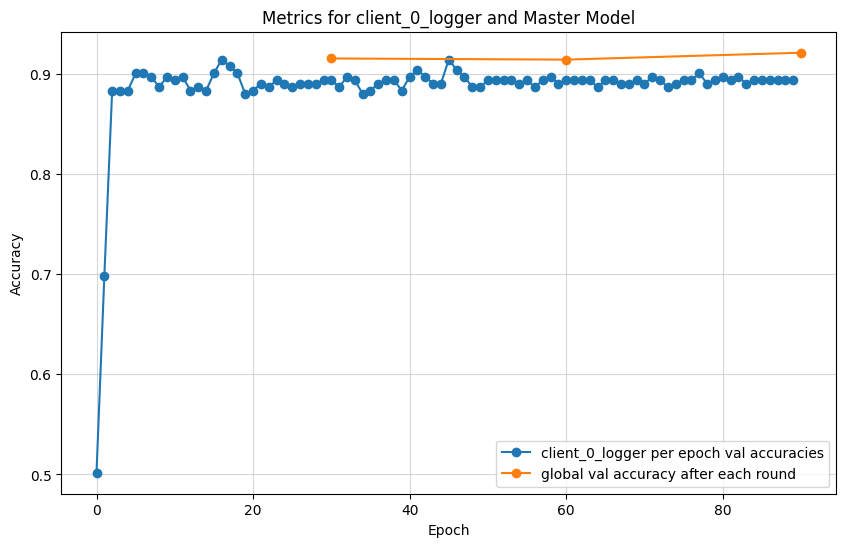

In [34]:
# Call the function
plot_metrics("client_0_logger")

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

num_epochs = 10
num_rounds = 3

def accumulate_client_metrics(client_name, base_path='/home/aladin/resilient_sfl/src/logs/clients'):
    client_dir = os.path.join(base_path, client_name)
    print(client_dir)
    rounds = [d for d in os.listdir(client_dir) if os.path.isdir(os.path.join(client_dir, d))]
    
    all_metrics = []
    for idx, r in enumerate(rounds):
        metrics_path = os.path.join(client_dir, r, 'metrics.csv')
        if os.path.exists(metrics_path):
            data = np.genfromtxt(metrics_path, delimiter=',', skip_header=1)
            if len(data.shape) == 1:  # if the data is 1D, reshape it
                data = data.reshape(1, -1)
            data[:, 2] += idx * num_epochs  # Update the epoch number by adding an offset
            all_metrics.append(data)
    
    accumulated_data = np.vstack(all_metrics)
    return accumulated_data

def accumulate_master_metrics(base_path='./logs/master'):
    train_dir = os.path.join(base_path, 'train')
    val_dir = os.path.join(base_path, 'validation')
    rounds = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
    
    all_train_metrics = []
    all_val_metrics = []
    for idx, r in enumerate(rounds):
        train_metrics_path = os.path.join(train_dir, r, 'metrics.csv')
        val_metrics_path = os.path.join(val_dir, r, 'metrics.csv')
        
        if os.path.exists(train_metrics_path):
            train_data = np.genfromtxt(train_metrics_path, delimiter=',', skip_header=1)
            if len(train_data.shape) == 1:  # if the data is 1D, reshape it
                train_data = train_data.reshape(1, -1)
            train_data[:, 2] += (idx + 1) * num_epochs  # Update the epoch number based on the round number
            all_train_metrics.append(train_data)
        
        if os.path.exists(val_metrics_path):
            val_data = np.genfromtxt(val_metrics_path, delimiter=',', skip_header=1)
            if len(val_data.shape) == 1:  # if the data is 1D, reshape it
                val_data = val_data.reshape(1, -1)
            val_data[:, 2] += (idx + 1) * num_epochs  # Update the epoch number based on the round number
            all_val_metrics.append(val_data)
    
    accumulated_train_data = np.vstack(all_train_metrics)
    accumulated_val_data = np.vstack(all_val_metrics)
    
    return accumulated_train_data, accumulated_val_data

def plot_metrics(client_name):
    # client_name = client_name.replace('_logger', '')
    client_data = accumulate_client_metrics(client_name)
    master_train_data, master_val_data = accumulate_master_metrics()
    
    plt.figure(figsize=(10, 6))
    
    # Plot metrics for client
    plt.plot(client_data[:, 2], client_data[:, 1], label=f'{client_name} per epoch val accuracies', linestyle='-', marker='o')
    plt.plot(client_data[:, 2], client_data[:, 4], label=f'{client_name} per epoch train accuracies', linestyle='-', marker='o')
    
    # Plot metrics for master model
    plt.plot(master_train_data[:, 2], master_train_data[:, 1], label='global train accuracy after each round', linestyle='-', marker='o')
    plt.plot(master_val_data[:, 2], master_val_data[:, 1], label='global val accuracy after each round', linestyle='-', marker='o')
    
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Metrics for {client_name} and Master Model')
    plt.legend()
    plt.grid(True)
    plt.show()


# Call the function
plot_metrics("client_0_logger")
